# Lecture 8 warm-up — Three games before we start

**AI-integrated Sustainable Finance (25881)**

Twenty minutes, three rounds, keep score. By the end you will have **invented NDVI yourself**,
without being shown the formula. That is not a figure of speech.

### What you need

Nothing. No installation, no account, no network, no data download. This notebook uses only
`numpy` and `matplotlib`, which every Python environment already has. It is deliberately
self-contained — it does not even use the `esgsat.py` helper the lab notebooks rely on, so it
runs on a locked-down machine, on Colab, or on a laptop you borrowed thirty seconds ago.

### The rules

| Round | The game | Points |
|---|---|---|
| 1 | **You are the satellite.** Identify six surfaces from numbers alone | 6 |
| 2 | **Colour is a choice.** Match four questions to four renderings | 4 |
| 3 | **Invent an index.** Beat the benchmark with two bands | 6 |

Play honestly. Guess *before* you run the reveal cell — the whole value is in being wrong
about something specific, and then finding out why.

## First, the one thing you need to know

A satellite does not take a photograph. It measures **how much light bounces back**, in
several narrow windows of the spectrum, and stores one number per window per pixel.

Your eye has three such windows: roughly red, green and blue. Sentinel-2 has thirteen. We will
use seven of them today.

| Band | Name | Wavelength | What it responds to |
|---|---|---|---|
| B02 | Blue | ~490 nm | Water, atmosphere, haze |
| B03 | Green | ~560 nm | The green you actually see in plants |
| B04 | Red | ~665 nm | Chlorophyll absorbs here, strongly |
| B05 | Red edge | ~705 nm | The steep transition at the edge of the visible |
| B08 | Near infrared | ~842 nm | Internal leaf structure scatters here |
| B11 | Shortwave infrared 1 | ~1610 nm | Water content, in leaves and in soil |
| B12 | Shortwave infrared 2 | ~2190 nm | Minerals, char, dry material |

**Hold on to one idea for the next twenty minutes.** Four of those seven bands are invisible
to you. That is not a technical detail — it is where nearly all of the information turns out
to live. Round 1 is designed to make you feel that rather than take my word for it.

In [1]:
# --- setup: numpy and matplotlib only -------------------------------------
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(25881)
SCORE = {"round1": 0, "round2": 0, "round3": 0}

BANDS = ["B02", "B03", "B04", "B05", "B08", "B11", "B12"]
BAND_NM = {"B02": 490, "B03": 560, "B04": 665, "B05": 705,
           "B08": 842, "B11": 1610, "B12": 2190}
BAND_ROLE = {"B02": "Blue", "B03": "Green", "B04": "Red", "B05": "Red edge",
             "B08": "NIR", "B11": "SWIR 1", "B12": "SWIR 2"}

# Representative surface reflectance for each land-cover type.
#
# These are STYLISED endmembers: the shape, the ordering and the magnitudes are
# right, but they are not measurements copied from a specific spectral library
# entry. For the real thing see the USGS Spectral Library or ECOSTRESS. Nothing
# in this warm-up depends on the third decimal place.
SIGNATURES = {
    "water":       [0.045, 0.055, 0.035, 0.025, 0.018, 0.008, 0.005],
    "vegetation":  [0.030, 0.060, 0.032, 0.120, 0.430, 0.200, 0.090],
    "bare soil":   [0.110, 0.150, 0.200, 0.240, 0.300, 0.360, 0.310],
    "snow":        [0.900, 0.910, 0.890, 0.860, 0.700, 0.090, 0.045],
    "urban":       [0.150, 0.170, 0.190, 0.200, 0.220, 0.250, 0.230],
    "burnt scar":  [0.060, 0.075, 0.100, 0.125, 0.150, 0.290, 0.300],
}
SURFACES = list(SIGNATURES)
print(f"{len(BANDS)} bands, {len(SURFACES)} surfaces. Ready.")

7 bands, 6 surfaces. Ready.


---
# Round 1 — You are the satellite

### Why we are doing this

Every automated analysis of satellite data — every land-cover map, every deforestation alert,
every carbon estimate — begins with an algorithm that has **never seen a picture**. It sees a
short vector of numbers per pixel and nothing else.

Before you trust such an algorithm, it is worth finding out whether *you* could do the job from
the same information. Most people discover two things: it is harder than expected, and the
part that helps most is the part they cannot see.

### What is about to happen

You get six mystery surfaces, labelled A to F. For each one you get seven numbers: the fraction
of incoming light reflected back in each band. A value of 0.43 means 43 per cent of the light
arriving in that band bounced back up to the satellite.

No image. No colours. No names. Just the numbers.

### What to expect

Two of the six are easy and you will get them almost immediately. One is genuinely hard, and it
is hard for an interesting reason rather than a trivial one. Before you start, make a
prediction: **which surface do you think will be hardest to identify from numbers alone, and
why?** Write it down. We will come back to it.

In [2]:
# The six mystery surfaces, in a shuffled order.
order = rng.permutation(len(SURFACES))
MYSTERY = {chr(65 + i): SURFACES[j] for i, j in enumerate(order)}   # the answer key
LETTERS = list(MYSTERY)

print("Reflectance, as a fraction of incoming light\n")
print(f"{'':6s}" + "".join(f"{b:>9s}" for b in BANDS))
print(f"{'':6s}" + "".join(f"{BAND_NM[b]:>8d}n" for b in BANDS))
print("-" * (6 + 9 * len(BANDS)))
for letter in LETTERS:
    vals = SIGNATURES[MYSTERY[letter]]
    print(f"  {letter}   " + "".join(f"{v:9.3f}" for v in vals))
print()
print("Your options:", ", ".join(sorted(SURFACES)))

Reflectance, as a fraction of incoming light

            B02      B03      B04      B05      B08      B11      B12
           490n     560n     665n     705n     842n    1610n    2190n
---------------------------------------------------------------------
  A       0.060    0.075    0.100    0.125    0.150    0.290    0.300
  B       0.045    0.055    0.035    0.025    0.018    0.008    0.005
  C       0.110    0.150    0.200    0.240    0.300    0.360    0.310
  D       0.030    0.060    0.032    0.120    0.430    0.200    0.090
  E       0.900    0.910    0.890    0.860    0.700    0.090    0.045
  F       0.150    0.170    0.190    0.200    0.220    0.250    0.230

Your options: bare soil, burnt scar, snow, urban, vegetation, water


### Make your guess

Edit the list below. One entry per letter, in order A, B, C, D, E, F. Spelling must match the
options exactly.

**Do not scroll past the next cell until you have committed to six answers.** Guessing and
being wrong is how this works.

In [3]:
# EDIT THIS. Six entries, in order A to F.
MY_GUESSES = [
    "?",   # A
    "?",   # B
    "?",   # C
    "?",   # D
    "?",   # E
    "?",   # F
]

if len(MY_GUESSES) != 6 or "?" in MY_GUESSES:
    print("Not finished yet. Replace every '?' with one of:")
    print("  " + ", ".join(sorted(SURFACES)))
else:
    bad = [g for g in MY_GUESSES if g not in SURFACES]
    print(f"Unrecognised: {bad}" if bad else "Six answers recorded. Run the next cell to score.")

Not finished yet. Replace every '?' with one of:
  bare soil, burnt scar, snow, urban, vegetation, water


Go back and fill in MY_GUESSES first.


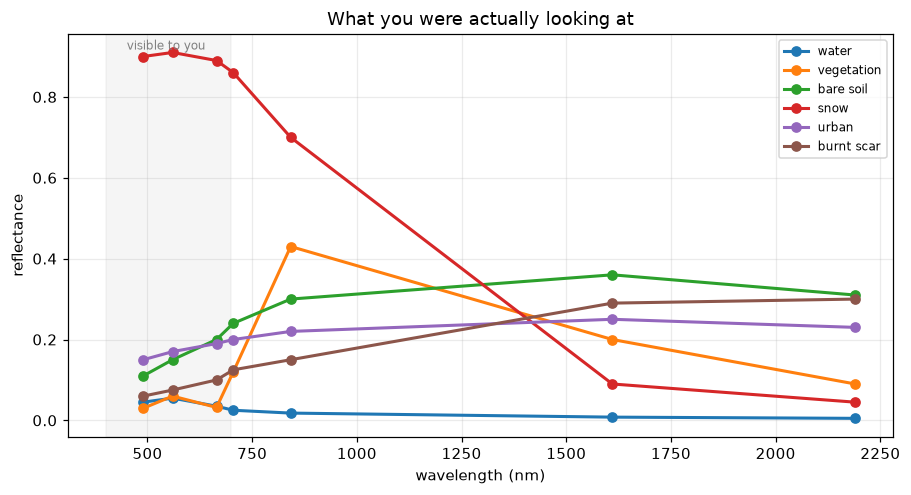

In [4]:
# --- reveal and score ------------------------------------------------------
if "?" in MY_GUESSES:
    print("Go back and fill in MY_GUESSES first.")
else:
    correct = 0
    print(f"{'':5s}{'your answer':<16s}{'truth':<16s}")
    print("-" * 40)
    for letter, guess in zip(LETTERS, MY_GUESSES):
        truth = MYSTERY[letter]
        hit = guess == truth
        correct += hit
        print(f"  {letter}  {guess:<16s}{truth:<16s}{'correct' if hit else ''}")
    SCORE["round1"] = correct
    print(f"\nRound 1 score: {correct} out of 6")

fig, ax = plt.subplots(figsize=(8.4, 4.6))
x = [BAND_NM[b] for b in BANDS]
for name, vals in SIGNATURES.items():
    ax.plot(x, vals, marker="o", lw=2, label=name)
ax.set_xlabel("wavelength (nm)"); ax.set_ylabel("reflectance")
ax.set_title("What you were actually looking at")
ax.axvspan(400, 700, alpha=0.08, color="grey")
ax.text(545, ax.get_ylim()[1] * 0.96, "visible to you", ha="center", fontsize=8, color="grey")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### How to read that plot

The grey band on the left is everything your eye can see. Look how little of the separation
happens inside it, and how much happens to the right.

Now the six surfaces one at a time. Each has a **diagnostic feature** — a single thing that
gives it away once you know to look.

**Water** — falls steadily and ends near zero. Water absorbs infrared almost completely, so
SWIR reflectance of about 0.005 is essentially a signature no other natural surface has. Easy,
once you know.

**Snow** — the opposite trick. Brilliant in the visible, and then it **collapses** in the
shortwave infrared. That collapse is why snow can be told apart from cloud, which stays bright
all the way across. Most people get snow right for the wrong reason: they spot the high visible
values and stop reading. Cloud looks identical there.

**Vegetation** — the famous shape. Low in red because chlorophyll absorbs it, then a **cliff**
up to 0.43 in the near infrared because the spongy interior of a leaf scatters it. That cliff
is the single most exploited feature in all of remote sensing, and you will exploit it yourself
in Round 3.

**Bare soil** — a smooth rise across the whole spectrum, peaking in SWIR 1. No cliff, no
collapse. Boring in a diagnostic way.

**Burnt scar** — this is the interesting one. It rises with wavelength like soil, so the two
look similar at first glance. The difference is the near infrared: burnt ground sits at 0.15
where soil sits at 0.30, because the leaf structure that scattered NIR has been destroyed. Char
and ash then push the SWIR bands up. Burnt ground is, in effect, **vegetation with its cliff
removed**.

**Urban** — the hardest, and it is hard for a reason worth naming. Concrete, asphalt and roofing
have **no diagnostic feature at all**. The line is nearly flat. There is nothing to spot,
because the surface is a mixture of manufactured materials that happen to average out. If you
guessed this one last, or got it by elimination, that is the correct experience.

### The takeaway from Round 1

Rank the bands by how much they helped you. Almost everyone produces the same ordering:
**SWIR and NIR did the work, the visible bands barely mattered.**

That is the first thing to carry into the lecture. When you read that a fund is using
"satellite imagery" to verify emissions or monitor a forestry project, the useful signal is
almost never in the part that looks like a photograph. If a vendor only ever shows you pretty
true-colour pictures, they are showing you the least informative bands they have.

---
# Round 2 — Colour is a choice

### Why we are doing this

You have seen satellite images in news reports, in annual reports, and in ESG marketing. They
look like photographs, so you read them like photographs.

They are not. A screen has three channels, the sensor has thirteen, and somebody chose which
three to show you. That choice is an analytical decision, and it changes what you notice.

### What is about to happen

We build one small synthetic scene containing water, healthy vegetation, bare soil, a built-up
area and a burn scar. Then we render **the same data four times**, changing only which band
goes to red, which to green, and which to blue.

### What to expect

The four images will look like four different places. They are not. Not one pixel of data
changes between them. Before you run it, predict: **which rendering do you think will make the
burn scar most obvious?**

In [5]:
# --- build one scene, once -------------------------------------------------
N = 220
yy, xx = np.mgrid[0:N, 0:N] / float(N)

CLASSES = ["water", "vegetation", "bare soil", "urban", "burnt scar"]
label = np.ones((N, N), dtype=int)                                   # vegetation
label[(xx < 0.30) & (yy > 0.62)] = 0                                 # a lake
label[np.abs(yy - 0.35 - 0.30 * xx) < 0.035] = 0                     # a river
label[(xx > 0.72) & (yy < 0.42)] = 2                                 # bare soil
label[(np.abs(xx - 0.46) < 0.11) & (np.abs(yy - 0.30) < 0.10)] = 3   # a town
burn = ((xx - 0.68) / 0.22) ** 2 + ((yy - 0.76) / 0.16) ** 2 < 1.0
label[burn & (label == 1)] = 4                                       # a burn scar

def smooth(a, k=5):
    '''Cheap box blur, so the noise is spatially correlated like real imagery.'''
    pad = k // 2
    ap = np.pad(a, pad, mode="reflect")
    c = np.pad(np.cumsum(np.cumsum(ap, 0), 1), ((1, 0), (1, 0)))
    h, w = a.shape
    return (c[k:k+h, k:k+w] - c[0:h, k:k+w] - c[k:k+h, 0:w] + c[0:h, 0:w]) / (k * k)

scene = {}
for j, b in enumerate(BANDS):
    base = np.zeros((N, N), dtype="float32")
    for code, name in enumerate(CLASSES):
        base = np.where(label == code, SIGNATURES[name][j], base)
    base += smooth(rng.normal(0, 0.015, (N, N)), 7) * 7
    scene[b] = np.clip(base, 0, 1)

print(f"Scene built: {N}x{N} pixels, {len(BANDS)} bands.")
for code, name in enumerate(CLASSES):
    print(f"  {name:12s} {float(np.mean(label == code))*100:5.1f}% of the scene")

Scene built: 220x220 pixels, 7 bands.
  water         18.3% of the scene
  vegetation    54.6% of the scene
  bare soil     11.7% of the scene
  urban          4.4% of the scene
  burnt scar    11.0% of the scene


### What is in this scene

Before you judge the four renderings, you need to know what you are looking at. Knowing the
layout does not spoil the game: Round 2 does not ask *where* the water is, it asks *which
rendering makes it obvious fastest*. You cannot judge that without knowing what is present.

The scene is 220 × 220 pixels. Five surfaces, each placed deliberately.

| Feature | Shape and position | Why it is there |
|---|---|---|
| **Vegetation** | The **background**. Everything not listed below, about 55% of the scene | The reference surface. Every other feature is a departure from it, which is how a real landscape works |
| **Lake** | A **rectangular block in the bottom-left corner**, roughly the left 30% and bottom 38% | Water as a large, easy target. Any competent rendering should find this |
| **River** | A **narrow diagonal strip about 15 pixels wide**, entering the left edge a third of the way down and leaving the right edge two-thirds of the way down | The same material as the lake, in a much harder geometry. Thin features are where spatial resolution starts to bite, and where a poor rendering loses the signal in the background |
| **Bare soil** | A **rectangular block in the top-right corner**, roughly the right 28% and top 42% | The thing burnt ground is most easily confused with. In true colour both are just brown |
| **Town** | A **small rectangle, a little left of centre and about 30% down**, roughly 48 × 44 pixels | The hardest feature, for the reason you met in Round 1: built surfaces have a nearly flat signature, so there is no diagnostic band to exploit |
| **Burn scar** | An **ellipse in the lower right**, wider than tall, centred about two-thirds across and three-quarters down | The scar only replaces vegetation, never the river or the town, so it has the ragged-edged look of a fire that stopped at a boundary |

### What to aim for

For each of the four questions below, the test is not "can I eventually find it" — with enough
squinting you can find most things in most renderings. The test is: **could you hand this
image to a colleague with no explanation and have them see it immediately?**

Two pairs are worth watching in particular.

- **The lake against the river.** A rendering that shows the lake clearly but loses the river
  is only half working. Water is water; the difference is size.
- **Bare soil against the burn scar.** These are the two brown blocks, and separating them is
  the single most useful thing a rendering can do here. One is ordinary ground, the other is a
  destroyed carbon stock, and in Lab 08b that difference becomes tonnes and then dollars.

### One honesty note

These shapes are rectangles and ellipses because the scene is synthetic. Real land cover is
irregular, gradual and mixed, and real boundaries are fuzzy over several pixels rather than
sharp. **This makes the game easier than reality**, which is the point for a twenty-minute
warm-up. Lab 08a puts you on a genuine Sentinel-2 scene where nothing has a clean edge.

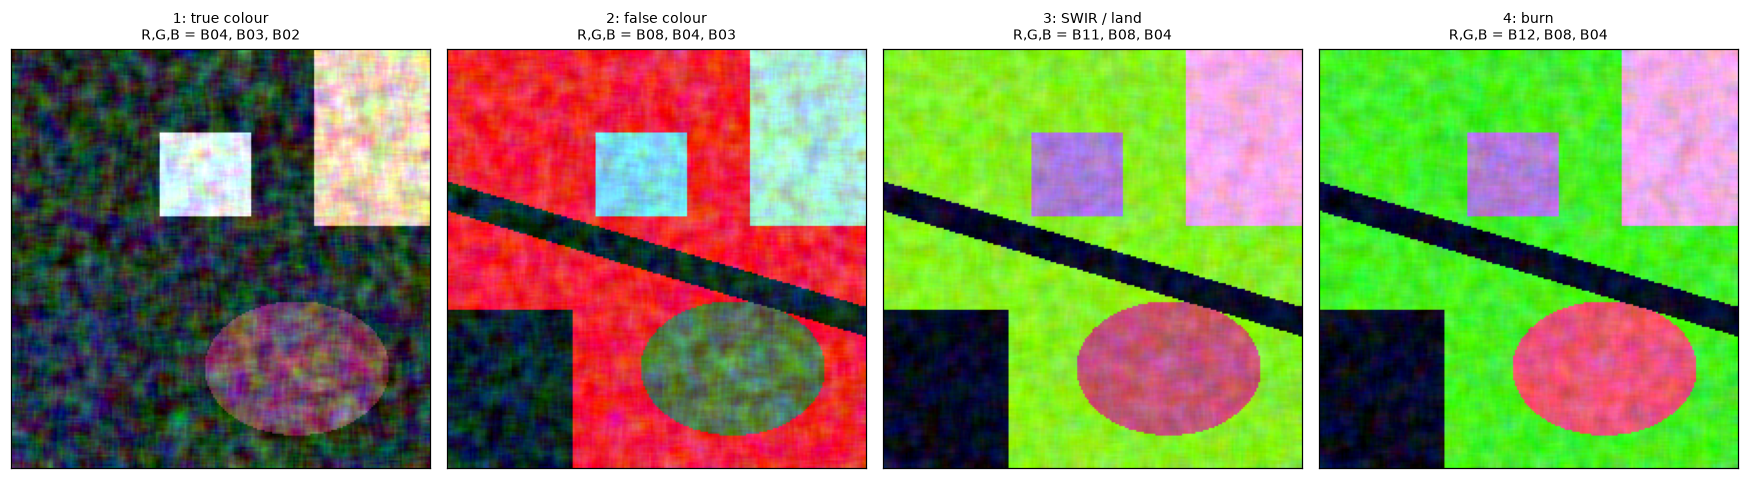

Identical data in all four. Only the choice of which three bands to display changed.


In [6]:
def composite(r, g, b, pct=(2, 98)):
    '''Map three chosen bands to the screen's red, green and blue channels.'''
    out = np.dstack([scene[r], scene[g], scene[b]]).astype("float32")
    for i in range(3):
        lo, hi = np.percentile(out[..., i], pct)
        out[..., i] = np.clip((out[..., i] - lo) / max(hi - lo, 1e-9), 0, 1)
    return out

RENDERS = {
    "1: true colour":   ("B04", "B03", "B02"),
    "2: false colour":  ("B08", "B04", "B03"),
    "3: SWIR / land":   ("B11", "B08", "B04"),
    "4: burn":          ("B12", "B08", "B04"),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, (title, bands) in zip(axes, RENDERS.items()):
    ax.imshow(composite(*bands))
    ax.set_title(f"{title}\nR,G,B = {', '.join(bands)}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print("Identical data in all four. Only the choice of which three bands to display changed.")

### Your task

Four questions. For each, decide which of the four renderings answers it **fastest** — not
which one is prettiest, but which one you could give to a colleague with no explanation.

1. Where is the water?
2. Where did it burn?
3. Where is the healthy vegetation?
4. Where is the bare ground?


In [7]:
# EDIT THIS. Four entries: the rendering number 1-4 that best answers each question.
MY_ANSWERS = {
    "water":      0,   # which rendering, 1-4?
    "burn":       0,
    "vegetation": 0,
    "bare":       0,
}

BEST = {"water": 3, "burn": 4, "vegetation": 2, "bare": 3}
WHY = {
 "water": "Rendering 3 puts SWIR1 in the red channel, and water is near-zero there, so it goes "
          "black against everything else. Rendering 1 shows water as dark grey-blue, which is "
          "also how shadow, asphalt and a burn scar look.",
 "burn":  "Rendering 4 puts SWIR2 in red and NIR in green. Burnt ground is high in SWIR2 and low "
          "in NIR, so it turns a distinct red-brown while living vegetation goes green. In true "
          "colour a burn scar and ploughed soil are both just brown.",
 "vegetation": "Rendering 2 is the classic: NIR in the red channel, so vegetation blazes red. "
          "It separates healthy from stressed vegetation far better than true colour, where "
          "everything green looks green.",
 "bare":  "Rendering 3 again. Bare soil peaks in SWIR1, so it dominates the red channel and "
          "appears bright, cleanly separated from vegetation.",
}

if 0 in MY_ANSWERS.values():
    print("Fill in all four first (values 1 to 4).")
else:
    got = 0
    for k, v in MY_ANSWERS.items():
        hit = v == BEST[k]
        got += hit
        print(f"{k:12s} you said {v}, best is {BEST[k]}  {'correct' if hit else ''}")
        print(f"             {WHY[k]}\n")
    SCORE["round2"] = got
    print(f"Round 2 score: {got} out of 4")

Fill in all four first (values 1 to 4).


### How to read that

There is no such thing as a neutral rendering. Every satellite image you have ever seen
embodies somebody's decision about what you should notice, and that decision was made before
you saw it.

Two consequences worth carrying into a professional setting.

**When you are shown an image, ask which bands.** "Satellite image of the project area" is not
a description. If the answer is always true colour, the presenter is either not analysing the
data or is choosing the rendering in which the problem is least visible.

**The contrast stretch is a choice too.** The `pct=(2, 98)` argument in the code above throws
away the brightest and darkest two per cent before scaling. Change it and the picture changes.
That is fine for display and fatal if done before computing a number — which is exactly the
kind of mistake Lab 08a is about.

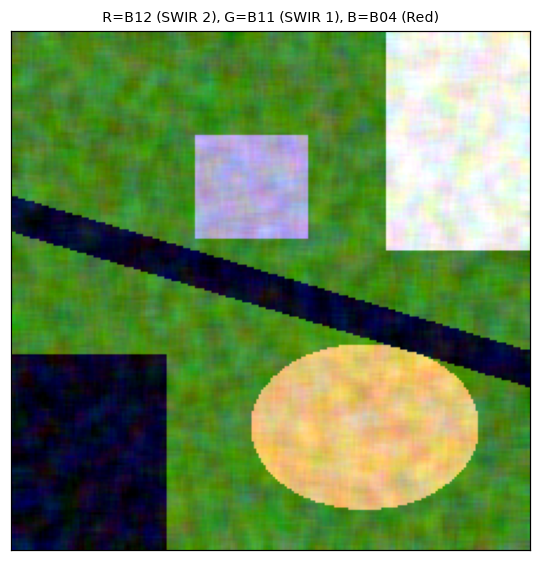

There are 7 x 6 x 5 = 210 orderings of three distinct bands from seven. Try a few.


In [8]:
# Optional: pick any three bands yourself and see what happens.
R, G, B = "B12", "B11", "B04"        # <- change these

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.imshow(composite(R, G, B))
ax.set_title(f"R={R} ({BAND_ROLE[R]}), G={G} ({BAND_ROLE[G]}), B={B} ({BAND_ROLE[B]})", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
print("There are 7 x 6 x 5 = 210 orderings of three distinct bands from seven. Try a few.")

---
# Round 3 — Invent an index

### Why we are doing this

You now have seven numbers per pixel. But a decision needs **one** number: is this pixel
vegetation or not, water or not, burnt or not. So the analytical problem is to squash seven
numbers into one, in a way that answers a particular question.

The move that the whole field is built on is embarrassingly simple. Pick two bands, and compute

$$\text{index} = \frac{A - B}{A + B}$$

That is it. That is the entire construction behind almost every index in remote sensing.

### Why the division, though?

Three reasons, and they are worth knowing because they explain what the index protects you
from and what it does not.

- **It cancels illumination.** A slope facing the sun receives more light, so *both* bands go
  up together, and the ratio barely moves. Without the division, every hillside would look like
  a different land cover.
- **It is bounded** between $-1$ and $+1$, which makes thresholds and colour scales behave.
- **It is dimensionless**, so different scenes and even different sensors become roughly
  comparable.

<details>
<summary><b>The maths, for those who want it</b></summary>

If both bands are scaled by the same positive factor $k$ — which is what a change in
illumination does to first order — then

$$\frac{kA - kB}{kA + kB} = \frac{k(A-B)}{k(A+B)} = \frac{A-B}{A+B}$$

so the index is invariant. Note carefully that this holds for a **multiplicative** change only.
Add a constant $c$ to both bands and

$$\frac{(A+c)-(B+c)}{(A+c)+(B+c)} = \frac{A-B}{A+B+2c} \neq \frac{A-B}{A+B}$$

The index is *not* invariant to an additive offset. That distinction looks pedantic here. In
Lab 08a it turns out to be the difference between a correct answer and a plausible wrong one.
</details>

### How we will score you

A good index makes two groups of pixels fall in different places. We measure that with a
**separability score**:

$$J = \frac{(\mu_{\text{target}} - \mu_{\text{other}})^2}{\sigma^2_{\text{target}} + \sigma^2_{\text{other}}}$$

In words: *how far apart are the two group averages, measured in units of how spread out the
groups are.* Distance between the peaks, divided by their width.

Higher is better. What counts as a good score depends on the question, so calibrate against
the field rather than against an absolute number. In this scene, across all 21 pairs:

| | vegetation | water | burnt scar |
|---|---|---|---|
| worst pair | 0.01 | 0.00 | 0.00 |
| median pair | 0.89 | 2.92 | 0.34 |
| **best pair** | **5.12** | **15.53** | **4.21** |

So the winner beats the typical pair by roughly five to twelve times. **That ratio is the
thing to aim at**, not any particular value of $J$.

<details>
<summary><b>Why are these numbers not larger?</b></summary>

We are scoring *one against the rest*, and "the rest" is a mixture of four different surfaces
sitting at four different places on the index. That makes $\sigma^2_{\text{other}}$ large by
construction, which pushes $J$ down no matter how good the index is.

Score vegetation against water alone and $J$ runs into the hundreds. The one-against-the-rest
number is the harder and more honest test, because it is the situation you are actually in:
you rarely get to assume the scene contains only two things.
</details>

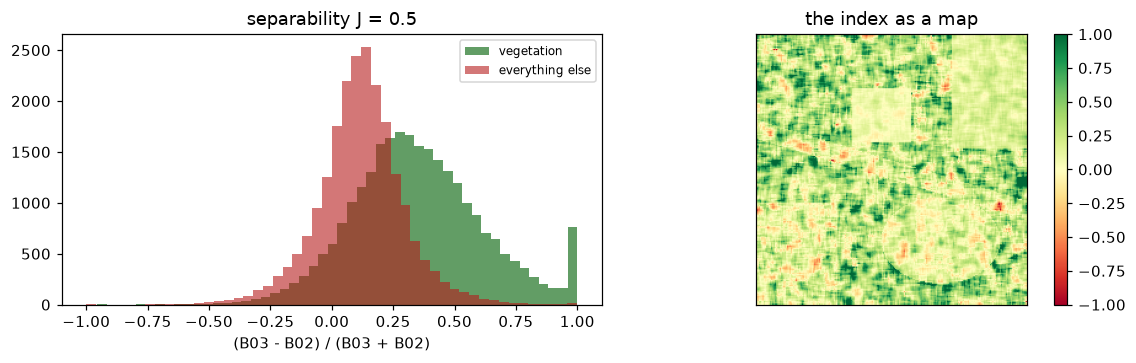

Green vs Blue, for vegetation:  J = 0.53
Two visible bands, right next to each other. They carry nearly the same information,
so their difference is mostly texture and noise. The best pair scores several times
this. Now go and find it.


In [9]:
def nd(a, b):
    '''The normalised difference of two bands.'''
    A, B = scene[a], scene[b]
    return (A - B) / np.where((A + B) == 0, np.nan, A + B)

def separability(index_values, target_code):
    '''Fisher separability of target pixels against everything else.'''
    v = np.asarray(index_values)
    t, o = v[label == target_code], v[label != target_code]
    t, o = t[np.isfinite(t)], o[np.isfinite(o)]
    return float((t.mean() - o.mean()) ** 2 / (t.var() + o.var()))

def try_index(a, b, target, show=True):
    '''Score a band pair against a target class, and show the two distributions.'''
    code = CLASSES.index(target)
    v = nd(a, b)
    J = separability(v, code)
    if show:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.4))
        ax1.hist(v[label == code], bins=50, alpha=0.75, label=target, color="#2E7D32")
        ax1.hist(v[label != code], bins=50, alpha=0.6, label="everything else", color="#B71C1C")
        ax1.set_xlabel(f"({a} - {b}) / ({a} + {b})"); ax1.legend(fontsize=8)
        ax1.set_title(f"separability J = {J:.1f}")
        im = ax2.imshow(v, cmap="RdYlGn", vmin=-1, vmax=1)
        ax2.set_title(f"the index as a map"); ax2.set_xticks([]); ax2.set_yticks([])
        fig.colorbar(im, ax=ax2, fraction=0.046)
        plt.tight_layout(); plt.show()
    return J

# A deliberately poor pair, to calibrate your expectations.
J0 = try_index("B03", "B02", "vegetation")
print(f"Green vs Blue, for vegetation:  J = {J0:.2f}")
print("Two visible bands, right next to each other. They carry nearly the same information,")
print("so their difference is mostly texture and noise. The best pair scores several times")
print("this. Now go and find it.")

### Play

Change `A` and `B` below and re-run. Your target is **vegetation**: find the pair that
separates vegetation from everything else as cleanly as possible.

**Think before you search.** You have seen the six signatures. Where is vegetation most unlike
everything else? A good index needs one band where the target is *high* and one where it is
*low* — a large gap, in both directions.

You have seven bands, so there are 21 distinct pairs. A room full of people can enumerate that
in a few minutes. Call out your best score.

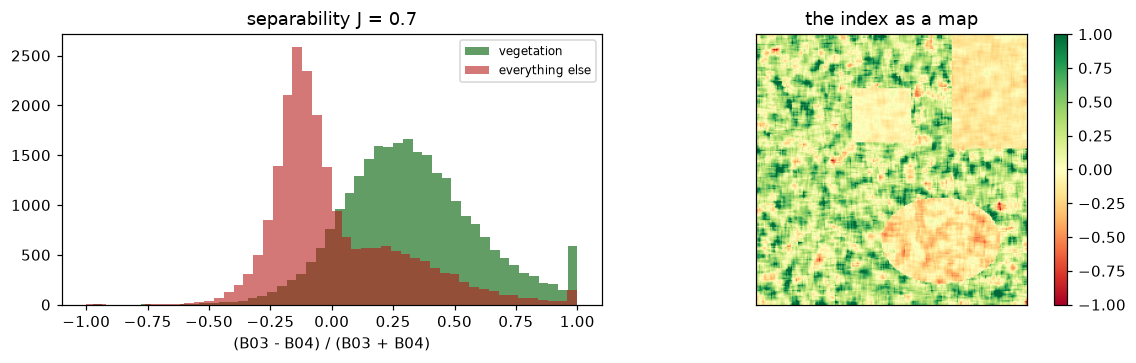

(B03 - B04) / (B03 + B04)  for  vegetation:   J = 0.66
floor (B03 vs B02) = 0.53


In [10]:
A, B = "B03", "B04"          # <- CHANGE THESE, then re-run. Choices from ["B02", "B03", "B04", "B05", "B08", "B11", "B12"]
TARGET = "vegetation"

J = try_index(A, B, TARGET)
print(f"({A} - {B}) / ({A} + {B})  for  {TARGET}:   J = {J:.2f}")
print(f"floor (B03 vs B02) = {J0:.2f}")

### The leaderboard

Once the room has had a go, run this. It scores **all 21 pairs** and ranks them.

Expect the top of the table to be dominated by pairs that straddle the red-edge cliff you saw
in Round 1: one band where vegetation is very low, one where it is very high.

In [11]:
def leaderboard(target, top=6):
    code = CLASSES.index(target)
    rows = []
    for i, a in enumerate(BANDS):
        for b in BANDS[i+1:]:
            v = nd(a, b)
            J = separability(v, code)
            # report the sign convention that makes the target positive
            sign = 1 if np.nanmean(v[label == code]) > np.nanmean(v[label != code]) else -1
            pair = (a, b) if sign > 0 else (b, a)
            rows.append((J, pair))
    rows.sort(reverse=True, key=lambda r: r[0])
    print(f"Best band pairs for  {target}\n")
    print(f"{'rank':>5s} {'index':<22s} {'J':>9s}   bands")
    print("-" * 62)
    for k, (J, (a, b)) in enumerate(rows[:top], 1):
        print(f"{k:5d} ({a} - {b})/({a} + {b}) {J:9.1f}   {BAND_ROLE[a]} vs {BAND_ROLE[b]}")
    print(f"{'':5s} ...")
    Jw, (a, b) = rows[-1]
    print(f"{len(rows):5d} ({a} - {b})/({a} + {b}) {Jw:9.1f}   {BAND_ROLE[a]} vs {BAND_ROLE[b]}")
    return rows

rows_veg = leaderboard("vegetation")

Best band pairs for  vegetation

 rank index                          J   bands
--------------------------------------------------------------
    1 (B08 - B04)/(B08 + B04)       5.2   NIR vs Red
    2 (B05 - B04)/(B05 + B04)       3.2   Red edge vs Red
    3 (B08 - B03)/(B08 + B03)       2.8   NIR vs Green
    4 (B08 - B02)/(B08 + B02)       2.6   NIR vs Blue
    5 (B08 - B05)/(B08 + B05)       2.5   NIR vs Red edge
    6 (B11 - B04)/(B11 + B04)       1.9   SWIR 1 vs Red
      ...
   21 (B02 - B04)/(B02 + B04)       0.0   Blue vs Red


### What just happened

The winner is **(B08 − B04) / (B08 + B04)**: near infrared minus red, over their sum.

That index has a name. It is the **Normalized Difference Vegetation Index**, published in 1974,
and it is the most widely used measurement in the history of Earth observation. It underpins
crop insurance, famine early warning, deforestation monitoring and a large share of the forest
carbon market.

You did not derive it from theory. You found it by searching 21 options and keeping the best
one. **That is exactly how it was found in the first place.**

Notice also how far ahead the winner is. This is not a marginal preference between similar
options — the right pair is dramatically better than the wrong pair. That gap is why indices
work at all.

In [12]:
# Two more targets. Same machinery, different question.
rows_water = leaderboard("water")
print()
rows_burnt = leaderboard("burnt scar")

Best band pairs for  water

 rank index                          J   bands
--------------------------------------------------------------
    1 (B03 - B11)/(B03 + B11)      15.3   Green vs SWIR 1
    2 (B02 - B11)/(B02 + B11)      12.4   Blue vs SWIR 1
    3 (B02 - B12)/(B02 + B12)      10.0   Blue vs SWIR 2
    4 (B03 - B12)/(B03 + B12)       9.8   Green vs SWIR 2
    5 (B03 - B08)/(B03 + B08)       8.6   Green vs NIR
    6 (B02 - B08)/(B02 + B08)       6.8   Blue vs NIR
      ...
   21 (B12 - B08)/(B12 + B08)       0.0   SWIR 2 vs NIR

Best band pairs for  burnt scar

 rank index                          J   bands
--------------------------------------------------------------
    1 (B12 - B08)/(B12 + B08)       4.2   SWIR 2 vs NIR
    2 (B12 - B05)/(B12 + B05)       3.4   SWIR 2 vs Red edge
    3 (B11 - B08)/(B11 + B08)       2.8   SWIR 1 vs NIR
    4 (B12 - B03)/(B12 + B03)       1.9   SWIR 2 vs Green
    5 (B04 - B03)/(B04 + B03)       1.6   Red vs Green
    6 (B12 - B02)/(B12 + B0

### Three questions, three different answers

| Target | Your winning pair | Its published name |
|---|---|---|
| Vegetation | NIR vs Red (B08, B04) | **NDVI**, Rouse et al. 1974 |
| Water | Green vs SWIR 1 (B03, B11) | **MNDWI**, Xu 2006 |
| Burnt ground | NIR vs SWIR 2 (B08, B12) | **NBR**, Key and Benson 2006 |

In about ten minutes you have re-derived three indices that took the field thirty years to
settle on, and you have done it by brute-force search over a tiny space.

**Three things follow, and they matter more than the trivia.**

**One number cannot answer every question.** The pair that is best for vegetation is not best
for water or for burn scars. There is no universal index, which is why the literature contains
hundreds of them. When someone offers you "the" satellite metric for an environmental claim,
the correct first question is: which question was it optimised for?

**An index is a feature that a human designed.** You chose the two inputs, you chose the
functional form, and you can explain both to an auditor in one sentence. That explainability is
not free — it is the direct consequence of the search space being small enough for you to
enumerate.

**You searched 21 options. What if you could search more?** You were restricted to two bands,
one functional form, and a single date. Suppose instead you used all thirteen bands,
non-linearly, across every satellite observation of a location for a whole year, and let an
optimiser find the combination. You would not be able to name the result or draw it on a
slide — but it would be better.

That is not hypothetical. It exists, it is free, and you will use it in Lab 08c.

In [13]:
# --- Round 3 scoring -------------------------------------------------------
# 2 points per target if your own best attempt got within 20% of the leaderboard winner.
BEST_J = {"vegetation": rows_veg[0][0], "water": rows_water[0][0], "burnt scar": rows_burnt[0][0]}

MY_BEST = {
    "vegetation": 0.0,     # <- put your best J for each target here
    "water":      0.0,
    "burnt scar": 0.0,
}

got = 0
for k, best in BEST_J.items():
    mine = MY_BEST.get(k, 0.0)
    pts = 2 if mine >= 0.8 * best else (1 if mine >= 0.4 * best else 0)
    got += pts
    print(f"{k:14s} yours {mine:9.1f}   best {best:9.1f}   {pts} point(s)")
SCORE["round3"] = got
print(f"\nRound 3 score: {got} out of 6")

vegetation     yours       0.0   best       5.2   0 point(s)
water          yours       0.0   best      15.3   0 point(s)
burnt scar     yours       0.0   best       4.2   0 point(s)

Round 3 score: 0 out of 6


In [14]:
total = sum(SCORE.values())
print("=" * 44)
print(f"{'FINAL SCORE':<30s}{total:>4d} / 16")
print("=" * 44)
for k, v in SCORE.items():
    print(f"  {k:<28s}{v:>4d}")
print()
print({True: "Well played.", False: "The score does not matter. The wrong answers do."}[total >= 12])

FINAL SCORE                      0 / 16
  round1                         0
  round2                         0
  round3                         0

The score does not matter. The wrong answers do.


---
## What you know now that you did not twenty minutes ago

1. **A satellite image is a vector of numbers per pixel, not a photograph.** You classified six
   surfaces from numbers alone, and you found out which ones resist it.

2. **The informative bands are the ones you cannot see.** NIR and SWIR did nearly all the work
   in every round. True colour is the least useful rendering there is.

3. **Every displayed image encodes somebody's choice.** Four renderings of identical data
   looked like four different places, and each one answered a different question best.

4. **An index is a hand-crafted feature, found by search.** You built NDVI, MNDWI and NBR
   yourself, by trying pairs and keeping what worked. Nobody derived them from first principles
   either.

5. **The search space was small enough for you to enumerate**, which is precisely why the
   result is interpretable. That trade-off — a small searchable space in exchange for
   explainability — is the central tension in the whole lecture.

## Where the lecture picks this up

We start with a question you are now equipped to answer properly: *where does a carbon number
actually come from?* Reported, modelled, or observed — and if observed, observed how, with what
uncertainty, and by whom.

Then the labs push what you built today all the way through. **08a** takes real Sentinel-2 data
and shows you two ways to break the indices you just invented. **08b** converts an index into
tonnes of CO₂ and then into dollars, keeping the error bars the whole way. **08c** replaces
your hand-built two-band feature with sixty-four learned ones and asks whether the trade is
worth it.

## Optional, if you finish early

**W1** Add `snow` to the scene and find the best index for it. Compare your answer with the
published NDSI. Then check what NDSI does to *water*, and explain the problem.

**W2** In Round 3 the scoring used only the top-ranked pair. Look at the second and third place
results for vegetation. How much worse are they, really, and would you notice the difference in
a map?

**W3** Real spectral signatures vary enormously with season, soil type, moisture and sun angle,
whereas ours are fixed. Look up the USGS Spectral Library or ECOSTRESS, find two genuine
measurements of the same cover type, and consider what their difference means for an index
threshold that someone calibrated in another country.